In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/2_M1_M2_group_level_plots'

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [4]:
# root_file = '/Users/f0053cz/Documents/psyanim_v2/playfight/10_read_data_final_task_wtraits/data/collected_data/main_data/'
# flname = 'final_data_triallevel_sorted'
root_file = '../../data/playfight_data/'
batch_name = 'final_data_triallevel_sorted_ses1'

In [5]:
# df = pd.read_csv('../data/all_dec_ses1.csv',index_col=[0])
df = pd.read_csv(f'{root_file}{batch_name}.csv')#,index_col=[0])
df.rename(columns = {'movie':'stim_file','responses':'aggressiveness_ratings','trial_num':'trial_ind'},inplace=True)
df.drop(columns=['Unnamed: 0'],inplace=True)
df.head() 

,subID,stimset_rows,chargeSpeeds,stim_dur,aggressiveness_ratings,RT,stim_file,trial_ind
0,26000,266,1.5,7761,13.0,1.51,e838dadb-c02f-4273-ae93-210720dcd06c,8
1,26000,266,1.5,7706,2.0,1.68,1f6c6525-a740-48c2-8dfc-9c4fb520c630,12
2,26000,266,1.5,7684,4.0,1.77,9d425f58-501f-43f3-955e-05126bd09bb5,15
3,26000,266,1.5,7672,2.0,1.53,1b1159fc-de2b-4ae5-a736-d98d8524a366,16
4,26000,266,1.5,7769,9.0,4.41,d3cc8306-21ab-4f88-ae4f-3970e4cd53ea,18


In [6]:
df.insert(5,'playfulness_ratings',100 - df['aggressiveness_ratings']) # convert responses from fightiness to playfulness
df

,subID,stimset_rows,chargeSpeeds,stim_dur,aggressiveness_ratings,playfulness_ratings,RT,stim_file,trial_ind
0,26000,266,1.5,7761,13.0,87.0,1.51,e838dadb-c02f-4273-ae93-210720dcd06c,8
1,26000,266,1.5,7706,2.0,98.0,1.68,1f6c6525-a740-48c2-8dfc-9c4fb520c630,12
2,26000,266,1.5,7684,4.0,96.0,1.77,9d425f58-501f-43f3-955e-05126bd09bb5,15
3,26000,266,1.5,7672,2.0,98.0,1.53,1b1159fc-de2b-4ae5-a736-d98d8524a366,16
4,26000,266,1.5,7769,9.0,91.0,4.41,d3cc8306-21ab-4f88-ae4f-3970e4cd53ea,18
...,...,...,...,...,...,...,...,...,...
22325,26348,245,9.0,7981,74.0,26.0,1.48,abb20336-74c4-448b-a5f7-252c765a55f4,31
22326,26348,245,9.0,7893,69.0,31.0,2.35,132133b4-5554-4500-9494-87f534100012,47
22327,26348,245,9.0,8018,100.0,0.0,1.39,059f8cfb-52c8-47fd-8d26-b0fec58eafae,52
22328,26348,245,9.0,7559,100.0,0.0,3.13,8e6be05b-c10c-43db-b062-a559f5033312,61


In [7]:
df.loc[np.isnan(df['playfulness_ratings']),:].groupby(['subID']).count().sort_values(by=['stim_file'])
# df.loc[np.isnan(df['aggressiveness_ratings']),:].groupby(['subID']).count().sort_values(by=['stim_file'])

,stimset_rows,chargeSpeeds,stim_dur,aggressiveness_ratings,playfulness_ratings,RT,stim_file,trial_ind
subID,,,,,,,,
26171,1,1,1,0,0,0,1,1
26226,1,1,1,0,0,0,1,1
26221,1,1,1,0,0,0,1,1
26213,1,1,1,0,0,0,1,1
26198,1,1,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...
26128,3,3,3,0,0,0,3,3
26333,3,3,3,0,0,0,3,3
26246,3,3,3,0,0,0,3,3


In [8]:
# jitter_strength = .1
chargeSpeed_array = np.unique(df['chargeSpeeds'])
chargeSpeed_array

array([1.5 , 2.75, 4.  , 5.25, 6.5 , 7.75, 9.  ])

In [9]:
df['condition'] = 'playfight'

In [10]:
nsubs = np.unique(df['subID']).shape[0]
nsubs

319

In [11]:
df['aggressiveness_ratings'] /= 100

In [12]:
palette = {'playfight':'tab:red'}

In [21]:
xspace = .03*(9-1.5) # 3% room on either sides of the lowest and highest xticks to match with the detection task
xspace

0.22499999999999998

In [22]:
1.5-xspace, 9+xspace

(1.275, 9.225)

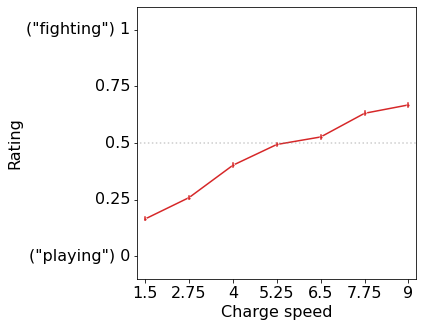

In [20]:
# sns.lineplot(data = df, x = 'chargeSpeeds', y = 'playfulness_ratings', hue = 'condition', marker = 'o', \
#     legend = False, palette=palette)
plt.figure(figsize=(5,5))
sns.lineplot(data = df, x = 'chargeSpeeds', y = 'aggressiveness_ratings', hue = 'condition', marker = '.', \
    legend = False, palette=palette, err_style='bars')
plt.hlines(.5,1,9.5,ls=':',color = 'grey', alpha = .4)
plt.ylim(-.1,1.1)
plt.ylabel('Rating')
plt.xlabel('Charge speed')
plt.xticks(chargeSpeed_array, ["1.5","2.75","4","5.25","6.5","7.75","9"],fontsize=16, ha='center')
plt.yticks(np.arange(0,1.01,.25),['("playing") 0',"0.25","0.5","0.75",'("fighting") 1'],fontsize=16,va='center',ha='right')
plt.xlim(1.275,9.225)
# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()

plt.savefig(f'../../results/playfight/ratings_group_playfight_{batch_name}_playfulness.png', dpi=300, bbox_inches='tight')

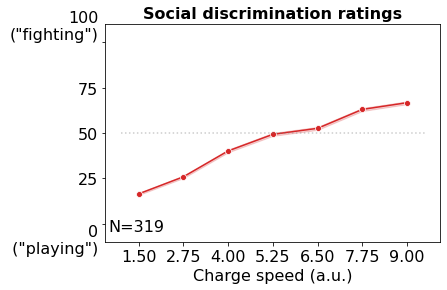

In [45]:
sns.lineplot(data = df, x = 'chargeSpeeds', y = 'aggressiveness_ratings', hue = 'condition', marker = 'o', palette=palette,legend = False, )
plt.hlines(50,1,9.5,ls=':',color = 'grey', alpha = .4)
plt.ylim(-10,110)
plt.title(f'Social discrimination ratings',fontweight = 'bold') # (n={nsubs})')
plt.gca().annotate(f'N={nsubs}',xy = (.01,.05),xycoords = 'axes fraction')
plt.ylabel('')
plt.xlabel('Charge speed (a.u.)')
plt.xticks(chargeSpeed_array,)
plt.yticks(np.arange(0,101,25),['0\n ("playing")',"25","50","75",'100\n("fighting")'])

# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()
labels[0].set_va('top')
labels[-1].set_va('bottom')

plt.savefig(f'../results/ratings_group_playfight_{batch_name}_aggressiveness.png', dpi=300, bbox_inches='tight')

In [41]:
dist_flname= '/Users/f0053cz/Documents/psyanim_v2/playfight/8_read_data_ratings/data/stim_info/confounds.csv'
df_dist = pd.read_csv(dist_flname, index_col=[0])
df_dist.rename(columns = {'metaData_flname':'stim_file','mean_dist':'avg_dist'},inplace=True)
df_dist.head()

,stim_ind,agent1_stateID,agent2_stateID,stim_file,chargeSpeed,all_dist,end_dist,avg_dist,std_dist,maxSpeeds,...,ncontacts,ncharges_state,ncharges_state_agent2,sceneKeys,userIDs,ncontacts-ncharges_state,ncontacts-ncharges_state_agent2,ntimepts,min_thr,diff_from_prev_level
0,0,88adff5a-f8fe-4c3e-98bc-3253af9853ba,81c8fb7b-d30f-4064-b497-59a047b96d14,b3a507ff-2289-4ad3-8922-1a3d0532e154,1.5,"[300.0, 299.079316293683, 298.23942913840006, ...",43.201982,218.344329,108.920035,1.419241,...,2.0,2,2,chSp1.5_ag1Lgrey_rep6_avgCDelay600,stimGen_playfight_v3_set1,0.0,0.0,474,0.0,1.419241
1,59,2dc1a238-19f3-428e-8b61-ef415eeb733b,be411823-fadd-4297-bf78-d13772681586,e838dadb-c02f-4273-ae93-210720dcd06c,1.5,"[300.0, 300.16203898498617, 300.3235528803621,...",119.088296,193.415055,92.040025,1.403698,...,2.0,2,2,chSp1.5_ag1Lgrey_rep9_avgCDelay600,stimGen_playfight_v3_set3,0.0,0.0,478,0.0,1.403698
2,138,d0d17ec8-784c-4491-ac58-e29d3e76afb1,1b7e26e0-afba-4b6d-b07a-d52faf4fbd2f,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,1.5,"[300.0, 298.69951690299814, 297.61342250339163...",64.097016,202.982646,93.077376,1.448190,...,2.0,2,2,chSp1.5_ag1Lblack_rep2_avgCDelay600,stimGen_playfight_v3_set19_8,0.0,0.0,480,0.0,1.448190
3,108,a8c9cf30-55ce-4707-bbb9-3f1ae411c5d6,ec4f8858-6ad6-4dcf-962f-83c58a6f3047,31e1789e-459a-4f3d-bfdd-2f4c8c4e9f50,1.5,"[300.0, 298.26838790324166, 296.6632438725617,...",31.292843,188.250786,80.513334,1.346242,...,2.0,2,2,chSp1.5_ag1Lgrey_rep8_avgCDelay600,stimGen_playfight_v3_set5,0.0,0.0,475,0.0,1.346242
4,126,9d32747c-692e-494f-98dd-e1495b00ae8e,486d2caf-3a15-4f6b-84ae-52daf460af44,7e595f18-f375-4ca5-b922-61b8d693804d,1.5,"[300.0, 299.67992852798346, 299.4203677703741,...",28.653805,204.081256,88.896476,1.381839,...,2.0,2,2,chSp1.5_ag1Lblack_rep1_avgCDelay600,stimGen_playfight_v3_set9,0.0,0.0,476,0.0,1.381839


In [42]:
df_dist.columns

Index(['stim_ind', 'agent1_stateID', 'agent2_stateID', 'stim_file',
       'chargeSpeed', 'all_dist', 'end_dist', 'avg_dist', 'std_dist',
       'maxSpeeds', 'charge_dur', 'charge_dist_traj',
       'charge_dist_traj_agent2', 'ncontacts', 'ncharges_state',
       'ncharges_state_agent2', 'sceneKeys', 'userIDs',
       'ncontacts-ncharges_state', 'ncontacts-ncharges_state_agent2',
       'ntimepts', 'min_thr', 'diff_from_prev_level'],
      dtype='object')

In [43]:
df_dist = df_dist[['stim_file','all_dist','avg_dist','charge_dist_traj']]
df_dist.head()

,stim_file,all_dist,avg_dist,charge_dist_traj
0,b3a507ff-2289-4ad3-8922-1a3d0532e154,"[300.0, 299.079316293683, 298.23942913840006, ...",218.344329,325.853920
1,e838dadb-c02f-4273-ae93-210720dcd06c,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864
2,29e7c94f-a6bf-4f1d-8ea1-46efbdb6a836,"[300.0, 298.69951690299814, 297.61342250339163...",202.982646,253.346655
3,31e1789e-459a-4f3d-bfdd-2f4c8c4e9f50,"[300.0, 298.26838790324166, 296.6632438725617,...",188.250786,223.594735
4,7e595f18-f375-4ca5-b922-61b8d693804d,"[300.0, 299.67992852798346, 299.4203677703741,...",204.081256,273.218830


In [44]:
df.shape, df_dist.shape

((22330, 10), (140, 4))

In [45]:
df_merged = df.merge(df_dist,how = 'inner', left_on = 'stim_file', right_on = 'stim_file')
df_merged.head()

,subID,stimset_rows,chargeSpeeds,stim_dur,aggressiveness_ratings,playfulness_ratings,RT,stim_file,trial_ind,condition,all_dist,avg_dist,charge_dist_traj
0,26000,266,1.5,7761,0.13,87.0,1.51,e838dadb-c02f-4273-ae93-210720dcd06c,8,playfight,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864
1,26001,360,1.5,8127,0.15,85.0,3.15,e838dadb-c02f-4273-ae93-210720dcd06c,44,playfight,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864
2,26002,256,1.5,8649,0.02,98.0,4.60,e838dadb-c02f-4273-ae93-210720dcd06c,53,playfight,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864
3,26003,381,1.5,8011,0.00,100.0,2.51,e838dadb-c02f-4273-ae93-210720dcd06c,39,playfight,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864
4,26004,161,1.5,8061,0.27,73.0,3.67,e838dadb-c02f-4273-ae93-210720dcd06c,63,playfight,"[300.0, 300.16203898498617, 300.3235528803621,...",193.415055,223.318864


In [46]:
df_merged.columns

Index(['subID', 'stimset_rows', 'chargeSpeeds', 'stim_dur',
       'aggressiveness_ratings', 'playfulness_ratings', 'RT', 'stim_file',
       'trial_ind', 'condition', 'all_dist', 'avg_dist', 'charge_dist_traj'],
      dtype='object')

In [47]:
df_merged = df_merged[['subID','chargeSpeeds','aggressiveness_ratings','playfulness_ratings','stim_file','trial_ind','avg_dist','charge_dist_traj']]
df_merged.describe()

,subID,chargeSpeeds,aggressiveness_ratings,playfulness_ratings,trial_ind,avg_dist,charge_dist_traj
count,22330.000000,22330.000000,22199.000000,22199.000000,22330.00000,22330.000000,22330.000000
mean,26175.799373,5.250000,0.448957,55.104329,34.50000,223.959631,271.798798
std,101.820779,2.500056,0.282607,28.260734,20.20565,22.731965,54.437145
min,26000.000000,1.500000,0.000000,0.000000,0.00000,176.652678,165.203391
25%,26088.000000,2.750000,0.220000,33.000000,17.00000,208.706432,226.485409
50%,26177.000000,5.250000,0.440000,56.000000,34.50000,222.795456,263.119309
75%,26266.000000,7.750000,0.670000,78.000000,52.00000,238.058023,315.817651
max,26348.000000,9.000000,1.000000,100.000000,69.00000,321.661257,397.803052


In [48]:
 # world size: 800 x 600.
max_dist = np.sqrt(800*800 + 600*600)
max_dist

1000.0

In [51]:
# df_merged['aggressiveness_ratings'] /= 100 
df_merged['playfulness_ratings'] /= 100 
df_merged['chargeSpeeds'] /= df_merged['chargeSpeeds'].max() 
# df_merged['chargeSpeeds_rev'] = 1-df_merged['chargeSpeeds']
df_merged['avg_dist'] /= max_dist#df_merged['avg_dist'].max()
df_merged['trial_ind'] /= df_merged['trial_ind'].max()
df_merged['charge_dist_traj'] /= df_merged['charge_dist_traj'].max()
df_merged

,subID,chargeSpeeds,aggressiveness_ratings,playfulness_ratings,stim_file,trial_ind,avg_dist,charge_dist_traj
0,26000,0.166667,0.13,0.87,e838dadb-c02f-4273-ae93-210720dcd06c,0.115942,0.193415,0.561380
1,26001,0.166667,0.15,0.85,e838dadb-c02f-4273-ae93-210720dcd06c,0.637681,0.193415,0.561380
2,26002,0.166667,0.02,0.98,e838dadb-c02f-4273-ae93-210720dcd06c,0.768116,0.193415,0.561380
3,26003,0.166667,0.00,1.00,e838dadb-c02f-4273-ae93-210720dcd06c,0.565217,0.193415,0.561380
4,26004,0.166667,0.27,0.73,e838dadb-c02f-4273-ae93-210720dcd06c,0.913043,0.193415,0.561380
...,...,...,...,...,...,...,...,...
22325,26342,0.444444,0.30,0.70,9f53cd68-f278-45d6-806a-74eeef55bbcc,0.304348,0.220299,0.721736
22326,26344,0.444444,0.20,0.80,9f53cd68-f278-45d6-806a-74eeef55bbcc,0.028986,0.220299,0.721736
22327,26345,0.444444,0.89,0.11,9f53cd68-f278-45d6-806a-74eeef55bbcc,0.231884,0.220299,0.721736
22328,26346,0.444444,0.53,0.47,9f53cd68-f278-45d6-806a-74eeef55bbcc,0.623188,0.220299,0.721736


In [52]:
df_merged.describe()

,subID,chargeSpeeds,aggressiveness_ratings,playfulness_ratings,trial_ind,avg_dist,charge_dist_traj
count,22330.000000,22330.000000,22199.000000,22199.000000,22330.000000,22330.000000,22330.000000
mean,26175.799373,0.583333,0.448957,0.551043,0.500000,0.223960,0.683250
std,101.820779,0.277784,0.282607,0.282607,0.292836,0.022732,0.136844
min,26000.000000,0.166667,0.000000,0.000000,0.000000,0.176653,0.415289
25%,26088.000000,0.305556,0.220000,0.330000,0.246377,0.208706,0.569341
50%,26177.000000,0.583333,0.440000,0.560000,0.500000,0.222795,0.661431
75%,26266.000000,0.861111,0.670000,0.780000,0.753623,0.238058,0.793905
max,26348.000000,1.000000,1.000000,1.000000,1.000000,0.321661,1.000000


In [53]:
df_merged['avg_dist'] -=  df_merged['avg_dist'].min()
df_merged['avg_dist'] /= df_merged['avg_dist'].max()
df_merged[ 'avg_dist'].describe()

count    22330.000000
mean         0.326236
std          0.156763
min          0.000000
25%          0.221047
50%          0.318207
75%          0.423460
max          1.000000
Name: avg_dist, dtype: float64

## LME

In [54]:
from pymer4.models import Lmer

In [55]:
missed_trials = df_merged.loc[np.isnan(df_merged['aggressiveness_ratings']),:].sort_values(by=['subID'])
missed_trials.head()

,subID,chargeSpeeds,aggressiveness_ratings,playfulness_ratings,stim_file,trial_ind,avg_dist,charge_dist_traj
15537,26001,0.861111,NaN,NaN,981d9d90-47c5-4443-a939-26060914c7e4,0.362319,0.563415,0.816416
17288,26001,1.000000,NaN,NaN,87da47db-3d5c-48b2-b3f2-123123d766f0,0.898551,0.426418,0.562298
4445,26008,0.444444,NaN,NaN,70326c05-1133-4c5d-8a4c-3e71e0da8479,0.043478,0.377474,0.787344
11264,26019,0.166667,NaN,NaN,95aaf072-b6be-4da4-9857-deaf20ab49f2,0.405797,0.326570,0.811772
8882,26031,0.861111,NaN,NaN,085d7298-e568-4752-a909-8eecf82e3ebc,0.202899,0.627154,0.915070


In [56]:
missed_trials.groupby(['subID']).count().sort_values(by=['stim_file'])

,chargeSpeeds,aggressiveness_ratings,playfulness_ratings,stim_file,trial_ind,avg_dist,charge_dist_traj
subID,,,,,,,
26171,1,0,0,1,1,1,1
26226,1,0,0,1,1,1,1
26221,1,0,0,1,1,1,1
26213,1,0,0,1,1,1,1
26198,1,0,0,1,1,1,1
...,...,...,...,...,...,...,...
26128,3,0,0,3,3,3,3
26333,3,0,0,3,3,3,3
26246,3,0,0,3,3,3,3


In [57]:
df_merged_nonan = df_merged.loc[~np.isnan(df_merged['aggressiveness_ratings']),:]

In [58]:
from scipy import stats
corr_ = df_merged_nonan.iloc[:,[1,4,5,6]].corr()
corr_

,chargeSpeeds,trial_ind,avg_dist
chargeSpeeds,1.000000,-0.001186,0.298117
trial_ind,-0.001186,1.000000,0.005947
avg_dist,0.298117,0.005947,1.000000


<AxesSubplot:>

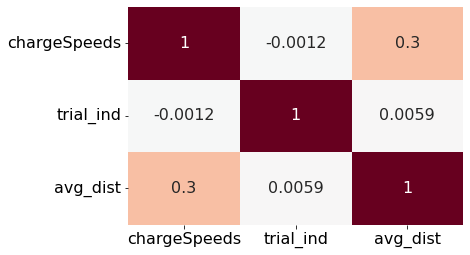

In [59]:
sns.heatmap(corr_,vmax=1,vmin=-1,cmap='RdBu_r',annot=True,cbar=False)

In [60]:
model = Lmer('playfulness_ratings ~ chargeSpeeds + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan) # ff: anglesm rfx: subject ID
model.fit()

Formula: playfulness_ratings~chargeSpeeds+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 22199	 Groups: {'subID': 319.0, 'stim_file': 140.0}

Log-likelihood: 3107.444 	 AIC: -6214.889

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.008  0.088
stim_file  (Intercept)  0.001  0.033
Residual                0.042  0.205

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.907,0.887,0.928,0.010,250.547,87.954,0.000,***
chargeSpeeds,-0.622,-0.645,-0.599,0.012,137.340,-52.546,0.000,***
avg_dist,0.057,0.016,0.098,0.021,137.537,2.699,0.008,**
trial_ind,-0.024,-0.033,-0.015,0.005,21790.168,-5.041,0.000,***


In [61]:
model = Lmer('aggressiveness_ratings ~ chargeSpeeds + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan) # ff: anglesm rfx: subject ID
model.fit()

Formula: aggressiveness_ratings~chargeSpeeds+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 22199	 Groups: {'subID': 319.0, 'stim_file': 140.0}

Log-likelihood: 3107.444 	 AIC: -6214.889

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.008  0.088
stim_file  (Intercept)  0.001  0.033
Residual                0.042  0.205

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.093,0.072,0.113,0.010,250.547,8.968,0.000,***
chargeSpeeds,0.622,0.599,0.645,0.012,137.340,52.546,0.000,***
avg_dist,-0.057,-0.098,-0.016,0.021,137.537,-2.699,0.008,**
trial_ind,0.024,0.015,0.033,0.005,21790.168,5.041,0.000,***


In [105]:
model = Lmer('aggressiveness_ratings ~ chargeSpeeds + charge_dist_traj + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan) # ff: anglesm rfx: subject ID
model.fit()

Formula: aggressiveness_ratings~chargeSpeeds+charge_dist_traj+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 22199	 Groups: {'subID': 319.0, 'stim_file': 140.0}

Log-likelihood: 3105.854 	 AIC: -6211.708

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.008  0.088
stim_file  (Intercept)  0.001  0.034
Residual                0.042  0.205

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.111,0.075,0.148,0.019,163.919,5.959,0.000,***
chargeSpeeds,0.611,0.589,0.634,0.011,137.229,53.385,0.000,***
charge_dist_traj,-0.045,-0.091,0.000,0.023,138.143,-1.948,0.053,.
trial_ind,0.024,0.015,0.033,0.005,21788.758,5.042,0.000,***
